In [135]:
import pandas as pd
data = pd.read_csv('data/online_retail_II.csv')
data.shape

(1067371, 8)

In [136]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# Valores ausentes

Qual a porcentagem de valores ausentes para cada atributo?

In [137]:
missing_percentage = data.isnull().sum() / data.shape[0] * 100
missing_percentage

InvoiceNo       0.000000
StockCode       0.000000
Description     0.410541
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     22.766873
Country         0.000000
dtype: float64

Mais de 22% dos clientes são desconhecidos! Além disso, temos 0,4% das descrições estão ausentes.

### Descrições ausentes

In [138]:
data[data.Description.isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


Com que frequência também deixamos de lado o cliente?

In [139]:
data[data.Description.isnull()].CustomerID.isnull().value_counts()

CustomerID
True    4382
Name: count, dtype: int64

E o preço unitário?

In [140]:
data[data.Description.isnull()].UnitPrice.value_counts()

UnitPrice
0.0    4382
Name: count, dtype: int64

Em casos de descrições ausentes, sempre faltam também o cliente e o preço unitário. Por que o varejista registra esse tipo de entrada sem uma descrição mais detalhada? Parece não haver um procedimento sofisticado para lidar com e registrar esse tipo de transação. Isso já indica que podemos esperar entradas estranhas em nossos dados e que pode ser difícil detectá-las!

### ID de clientes ausentes

In [141]:
data[data.CustomerID.isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom


In [142]:
data.loc[data.CustomerID.isnull(), ["UnitPrice", "Quantity"]].describe()

,UnitPrice,Quantity
count,243007.000000,243007.000000
mean,7.948744,1.540548
std,224.275451,98.859370
min,-53594.360000,-9600.000000
25%,1.660000,1.000000
50%,3.290000,1.000000
75%,5.790000,2.000000
max,25111.090000,10200.000000


Isso também é ruim. O preço e a quantidade de itens sem um ID de cliente podem apresentar valores discrepantes extremos. Como podemos querer criar funcionalidades posteriormente com base em preços históricos e quantidades vendidas, isso é muito prejudicial. Nossa primeira recomendação para o lojista é configurar estratégias para transações que apresentem algum tipo de falha ou sejam especiais. E a pergunta permanece: por que é possível que uma transação ocorra sem um ID de cliente? Talvez seja possível comprar como visitante, mas, nesse caso, seria uma prática melhor e mais organizada adicionar um ID especial que indique que se trata de um visitante. Ok, próxima pergunta: temos valores NaN ocultos nas descrições? Para descobrir, vamos criar uma nova funcionalidade que armazene as descrições em letras minúsculas:

### Descrições ocultas ausentes

Podemos encontrar strings "nan"?

In [143]:
import numpy as np
data.loc[data.Description.isnull()==False, "lowercase_descriptions"] = data.loc[
    data.Description.isnull()==False,"Description"
].apply(lambda l: l.lower())

data.lowercase_descriptions.dropna().apply(
    lambda l: np.where("nan" in l, True, False)
).value_counts()

lowercase_descriptions
False    1061843
True        1146
Name: count, dtype: int64

Podemos encontrar strings vazias ""?

In [144]:
data.lowercase_descriptions.dropna().apply(
    lambda l: np.where("" == l, True, False)
).value_counts()

lowercase_descriptions
False    1062989
Name: count, dtype: int64

Encontramos valores NaN adicionais e ocultos que exibem a string "nan" em vez do valor NaN. Vamos transformá-los em NaN:

In [145]:
data.loc[data.lowercase_descriptions.isnull()==False, "lowercase_descriptions"] = data.loc[
    data.lowercase_descriptions.isnull()==False, "lowercase_descriptions"
].apply(lambda l: np.where("nan" in l, None, l))

Como não sabemos por que faltam clientes ou descrições, e observamos anomalias estranhas em quantidades e preços, bem como preços zerados, vamos agir com cautela e descartar todas essas ocorrências.

In [146]:
print("Antes:", len(data))

Antes: 1067371


In [147]:
data = data.loc[(data.CustomerID.isnull()==False) & (data.lowercase_descriptions.isnull()==False)].copy()

In [148]:
print("Depois:", len(data))

Depois: 823429


Só para ter certeza: ainda falta algum valor?

In [149]:
data.isnull().sum().sum()

np.int64(0)

# Período de tempo

Qual a duração desse período em dias?

In [150]:
data["InvoiceDate"] = pd.to_datetime(data.InvoiceDate, cache=True)
data.InvoiceDate.max() - data.InvoiceDate.min()

Timedelta('738 days 05:05:00')

In [151]:
print("Começa: {}".format(data.InvoiceDate.min()))
print("Termina: {}".format(data.InvoiceDate.max()))

Começa: 2009-12-01 07:45:00
Termina: 2011-12-09 12:50:00


# Número da fatura

Quantos números de fatura diferentes temos?

In [152]:
data.InvoiceNo.nunique()

44866

Na descrição dos dados, podemos ver que as transações canceladas começam com um "C" no início. Vamos criar uma funcionalidade para filtrar facilmente esses casos:

In [153]:
data["IsCancelled"]=np.where(data.InvoiceNo.apply(lambda l: l[0]=="C"), True, False)
data.IsCancelled.value_counts() / data.shape[0] * 100

IsCancelled
False    97.725973
True      2.274027
Name: count, dtype: float64

2,3% de todas as transações são cancelamentos.

In [154]:
data.loc[data.IsCancelled==True].describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,18725.000000,18725,18725.000000,18725.000000
mean,-25.989212,2010-12-11 13:26:47.336715776,23.922300,15014.651162
min,-80995.000000,2009-12-01 10:33:00,0.010000,12346.000000
25%,-6.000000,2010-06-07 10:50:00,1.450000,13552.000000
50%,-2.000000,2010-11-26 17:10:00,2.950000,14911.000000
75%,-1.000000,2011-06-29 13:29:00,5.950000,16401.000000
max,-1.000000,2011-12-09 11:58:00,38970.000000,18287.000000
std,821.456875,NaN,424.409299,1698.714561


Todos os cancelamentos têm quantidades negativas, mas preços unitários positivos e diferentes de zero. Com esses dados, não conseguimos entender facilmente por que um cliente fez uma devolução e é muito difícil prever esses casos, pois pode haver vários motivos ocultos para um cancelamento. Vamos descartá-los:

In [155]:
print("Antes:", len(data))

Antes: 823429


In [156]:
data = data.loc[data.IsCancelled==False].copy()
data = data.drop("IsCancelled", axis=1)

In [157]:
print("Depois:", len(data))

Depois: 804704


# Stockcodes

Quantos códigos de ações exclusivos temos?

In [158]:
data.StockCode.nunique()

4629

Quais são os códigos mais comuns?

/tmp/ipykernel_118024/355008602.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


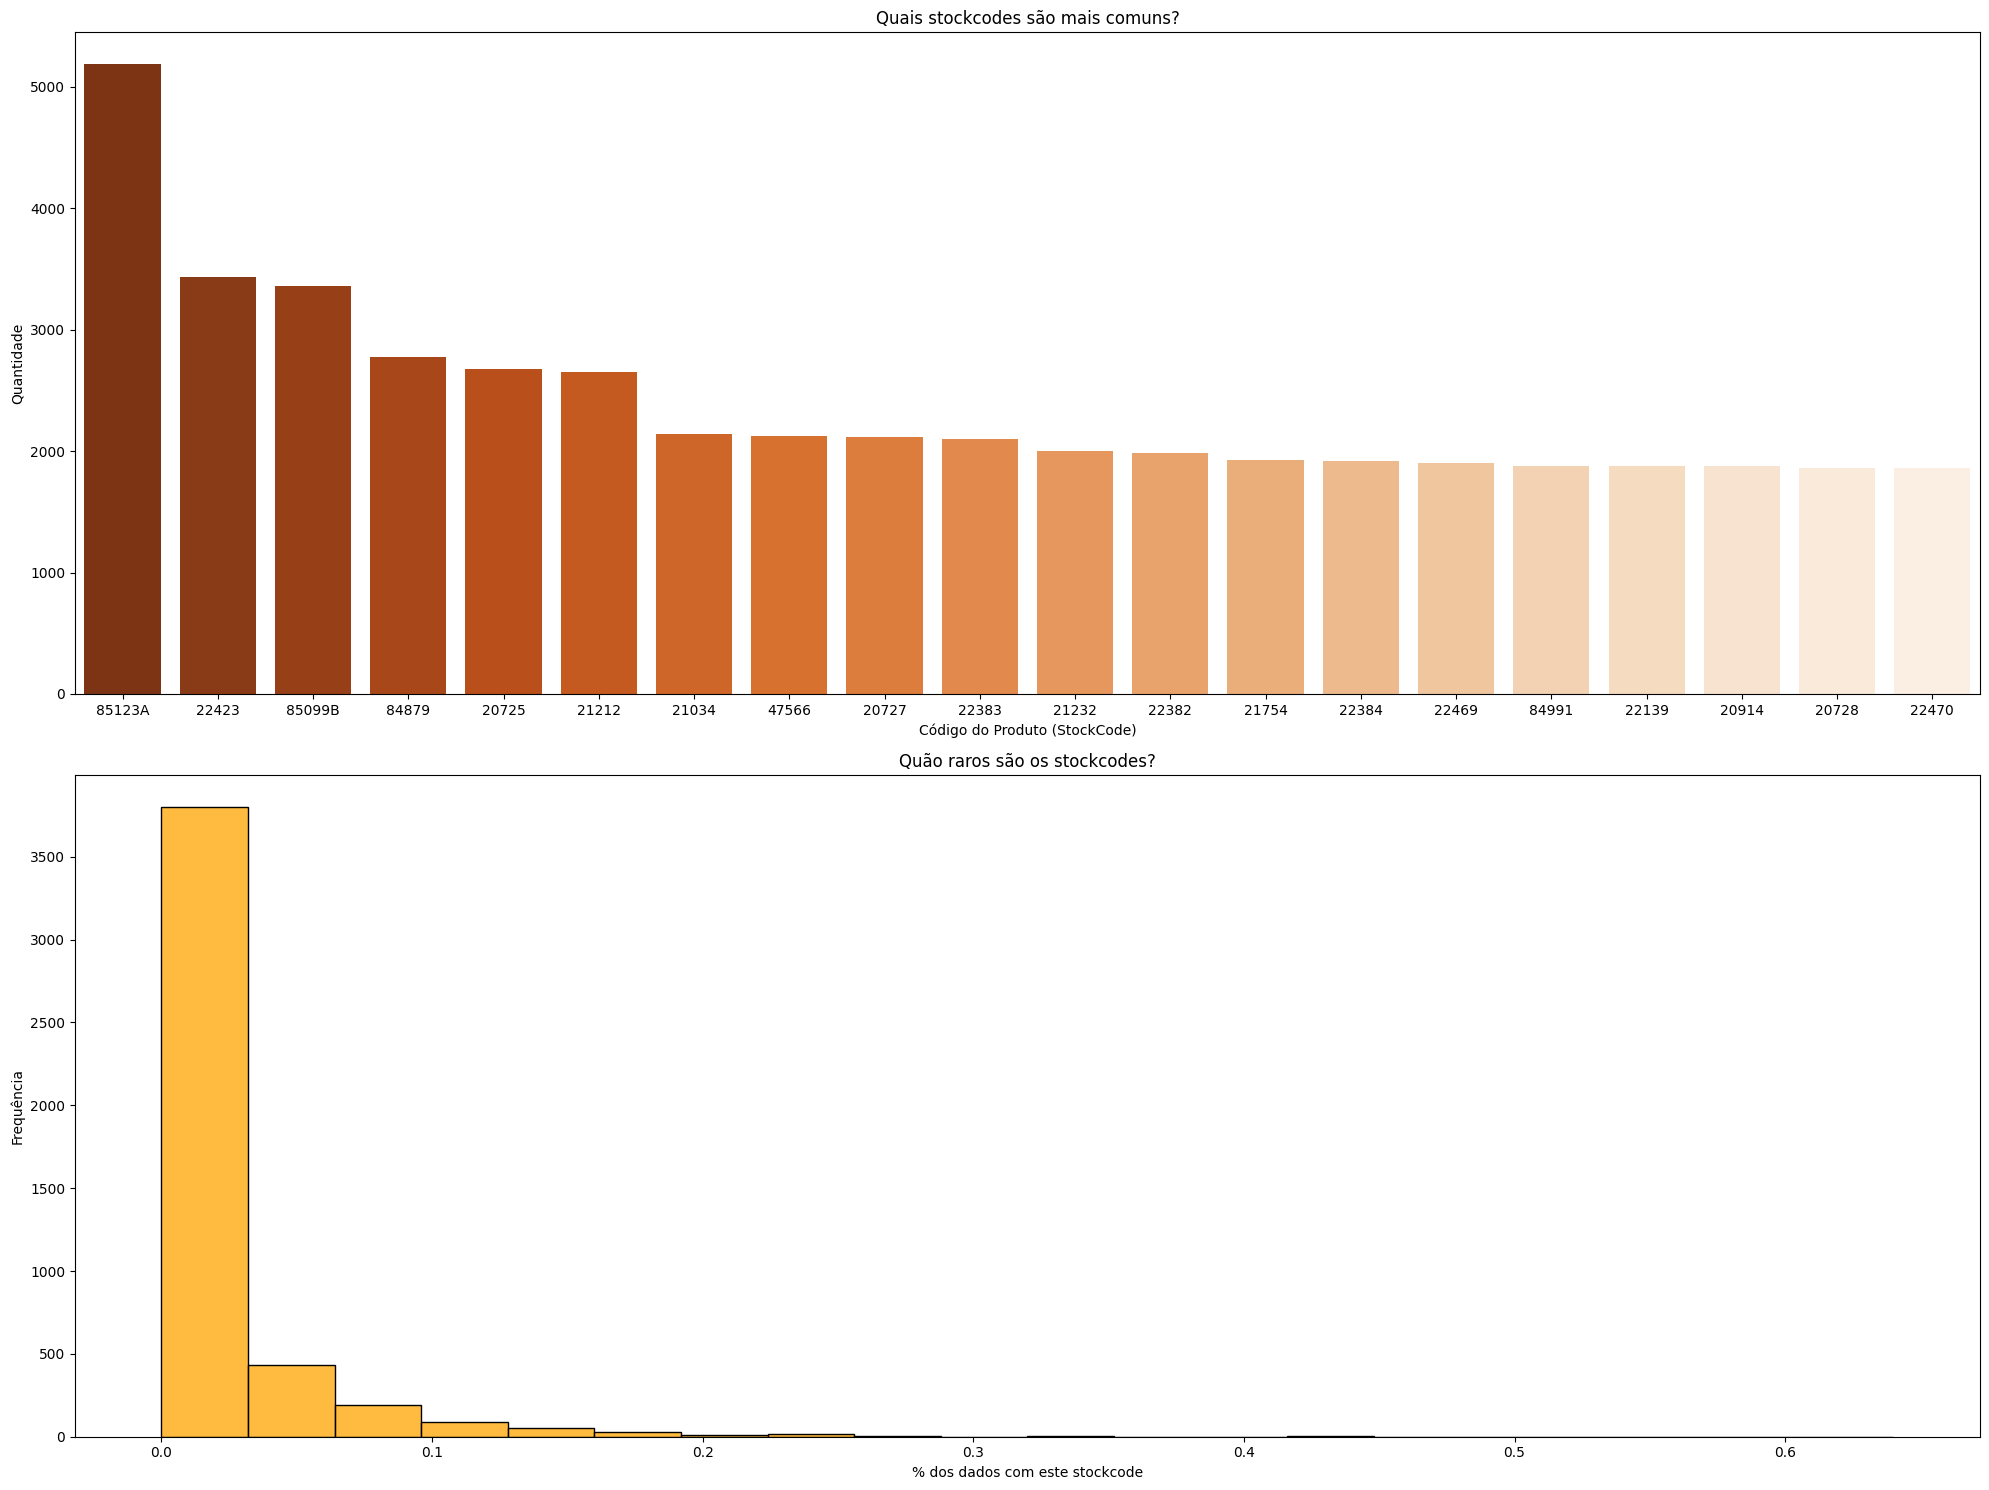

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Contagem de ocorrências de cada código de produto (StockCode)
contagem_stockcode = data.StockCode.value_counts().sort_values(ascending=False)

# Criação da figura com dois subgráficos
fig, ax = plt.subplots(2, 1, figsize=(20, 15))

# Gráfico de barras: 20 stockcodes mais comuns
sns.barplot(
    x=contagem_stockcode.iloc[:20].index,
    y=contagem_stockcode.iloc[:20].values,
    ax=ax[0],
    palette="Oranges_r"
)

ax[0].set_ylabel("Quantidade")
ax[0].set_xlabel("Código do Produto (StockCode)")
ax[0].set_title("Quais stockcodes são mais comuns?")

# Histograma: porcentagem de registros por stockcode
sns.histplot(
    np.round(contagem_stockcode / data.shape[0] * 100, 2),
    bins=20,
    ax=ax[1],
    color="Orange"
)

ax[1].set_title("Quão raros são os stockcodes?")
ax[1].set_xlabel("% dos dados com este stockcode")
ax[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

Vamos contar o número de caracteres numéricos e o comprimento do StockCode:

In [160]:
def count_numeric_chars(l):
    return sum(1 for c in l if c.isdigit())

data["StockCodeLength"] = data.StockCode.apply(lambda l: len(l))
data["nNumericStockCode"] = data.StockCode.apply(lambda l: count_numeric_chars(l))

/tmp/ipykernel_118024/1284711394.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_118024/1284711394.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


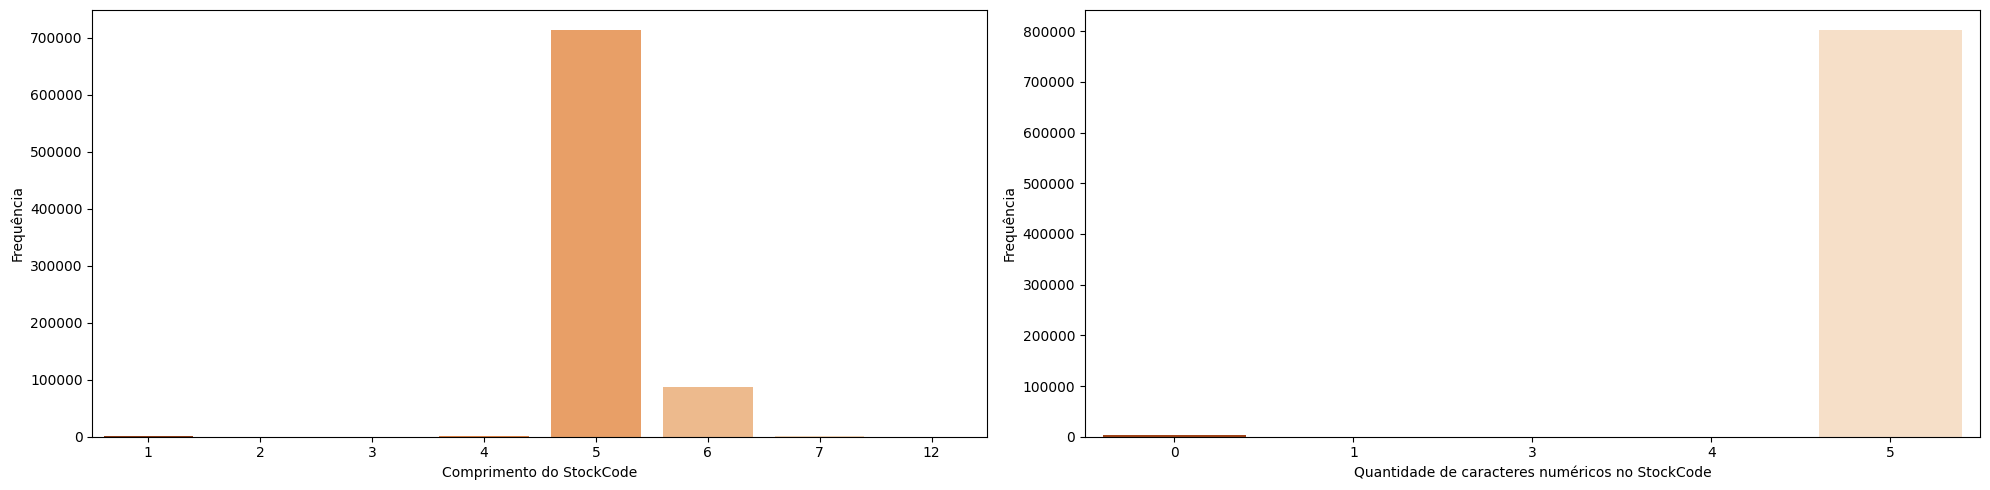

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criação da figura com dois subgráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

# Gráfico de contagem: tamanho (comprimento) do StockCode
sns.countplot(
    x=data["StockCodeLength"],
    palette="Oranges_r",
    ax=ax[0]
)

# Gráfico de contagem: quantidade de caracteres numéricos no StockCode
sns.countplot(
    x=data["nNumericStockCode"],
    palette="Oranges_r",
    ax=ax[1]
)

ax[0].set_xlabel("Comprimento do StockCode")
ax[0].set_ylabel("Frequência")

ax[1].set_xlabel("Quantidade de caracteres numéricos no StockCode")
ax[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

Embora a maioria das amostras apresente um StockCode com 5 caracteres numéricos, podemos observar outras ocorrências. O comprimento pode variar entre 1 e 12 caracteres, e existem StockCodes sem nenhum caractere numérico!

In [162]:
data.loc[data.nNumericStockCode < 5].lowercase_descriptions.value_counts()

lowercase_descriptions
postage                                1838
manual                                  716
carriage                                253
bank charges                             30
pads to match all cushions               18
adjustment by john on 26/01/2010 16      18
dotcom postage                           16
adjustment by john on 26/01/2010 17      14
this is a test product.                  12
discount                                  5
adjustment by peter on jun 25 2010        3
 bank charges                             2
kid's chalkboard/easel                    2
Name: count, dtype: int64

In [163]:
print("Antes:", len(data))

Antes: 804704


In [164]:
data = data.loc[(data.nNumericStockCode == 5) & (data.StockCodeLength==5)].copy()
data.StockCode.nunique()

3319

In [165]:
print("Depois:", len(data))

Depois: 713132


In [166]:
data = data.drop(["nNumericStockCode", "StockCodeLength"], axis=1)

# Descrições

Quantas descrições únicas temos?

In [167]:
data.Description.nunique()

3891

E quais são os mais comuns?

/tmp/ipykernel_118024/2999851691.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


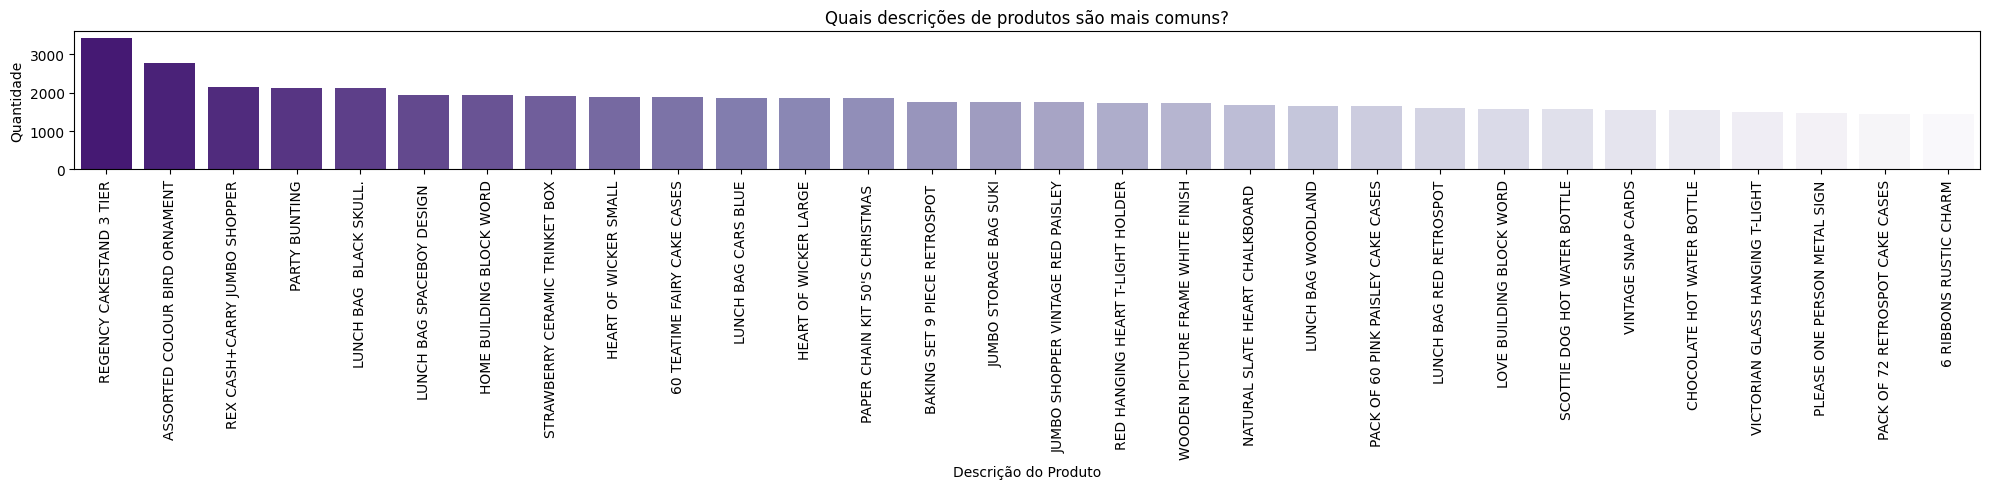

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem das descrições de produtos mais frequentes (top 30)
contagem_descricoes = (
    data.Description.value_counts()
    .sort_values(ascending=False)
    .iloc[:30]
)

# Criação da figura
plt.figure(figsize=(20, 5))

# Gráfico de barras das descrições mais comuns
sns.barplot(
    x=contagem_descricoes.index,
    y=contagem_descricoes.values,
    palette="Purples_r"
)

plt.ylabel("Quantidade")
plt.xlabel("Descrição do Produto")
plt.title("Quais descrições de produtos são mais comuns?")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [169]:
def count_lower_chars(l):
    return sum(1 for c in l if c.islower())

In [170]:
data["DescriptionLength"] = data.Description.apply(lambda l: len(l))
data["LowCharsInDescription"] = data.Description.apply(lambda l: count_lower_chars(l))

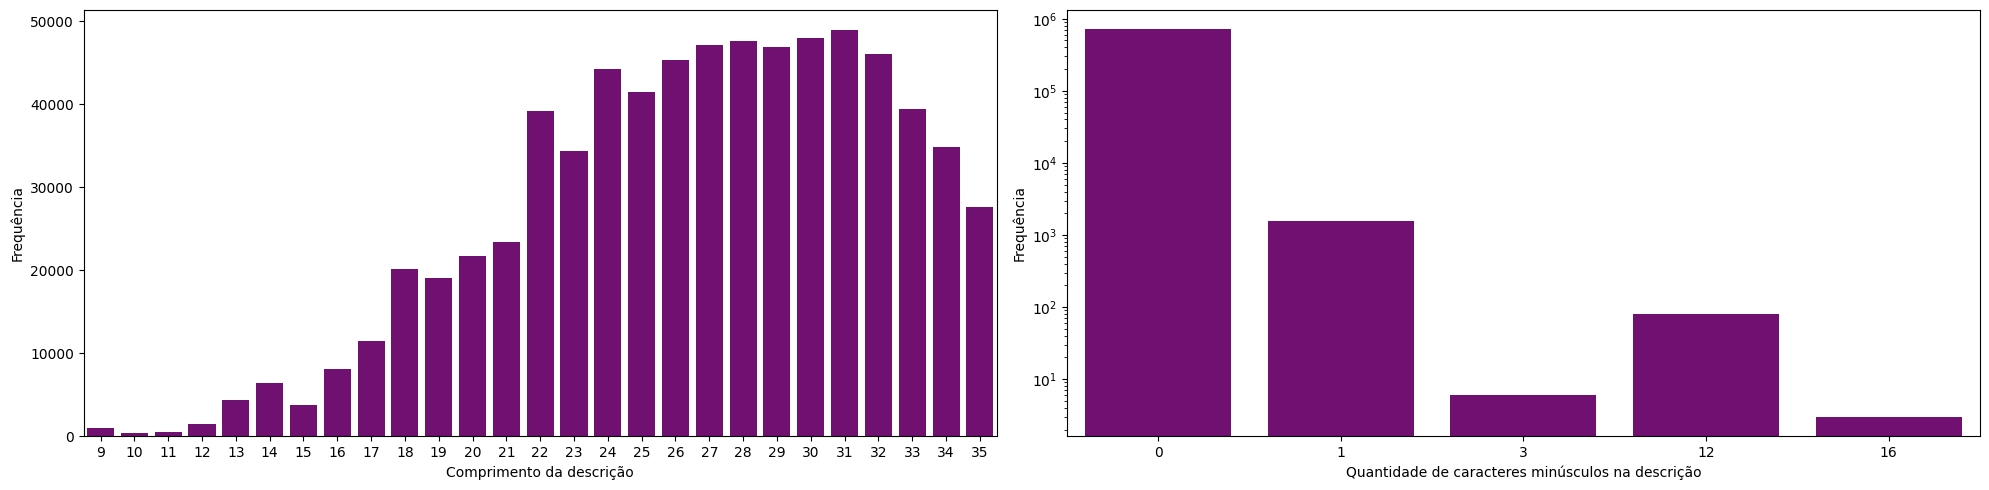

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criação da figura com dois subgráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

# Gráfico de contagem: comprimento da descrição do produto
sns.countplot(
    x=data.DescriptionLength,
    ax=ax[0],
    color="Purple"
)

ax[0].set_xlabel("Comprimento da descrição")
ax[0].set_ylabel("Frequência")

# Gráfico de contagem: quantidade de caracteres minúsculos na descrição
sns.countplot(
    x=data.LowCharsInDescription,
    ax=ax[1],
    color="Purple"
)

ax[1].set_xlabel("Quantidade de caracteres minúsculos na descrição")
ax[1].set_ylabel("Frequência")

# Escala logarítmica no eixo Y do segundo gráfico
ax[1].set_yscale("log")

plt.tight_layout()
plt.show()

/tmp/ipykernel_118024/2972716586.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_118024/2972716586.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


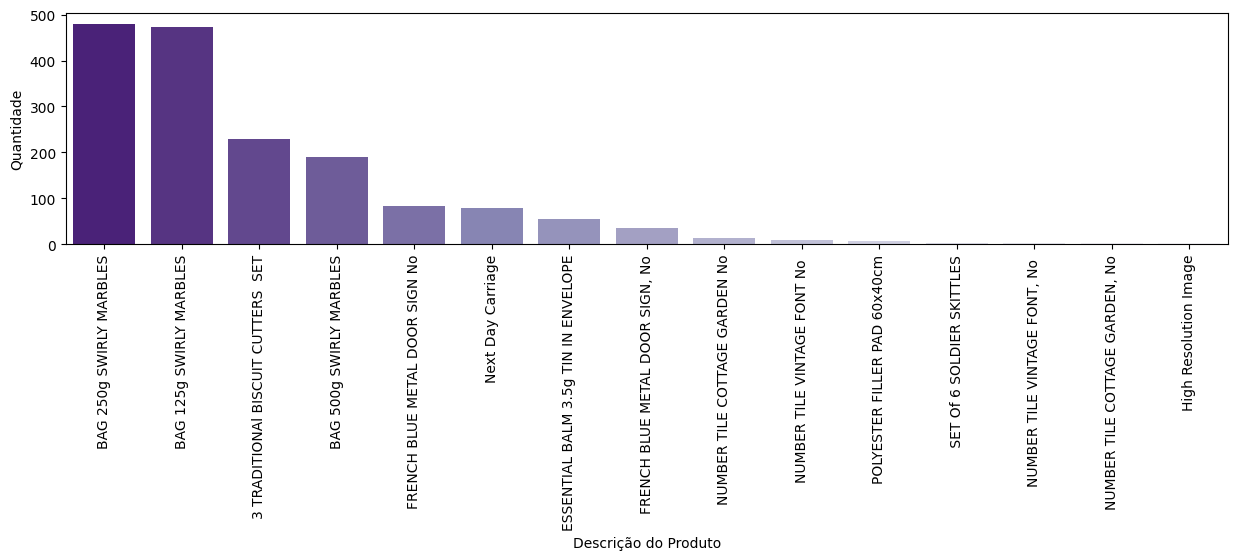

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem das descrições que possuem caracteres minúsculos
contagem_descricoes_com_minusculas = (
    data.loc[data.LowCharsInDescription > 0, "Description"]
    .value_counts()
)

# Criação da figura
plt.figure(figsize=(15, 3))

# Gráfico de barras das descrições com caracteres minúsculos
sns.barplot(
    x=contagem_descricoes_com_minusculas.index,
    y=contagem_descricoes_com_minusculas.values,
    palette="Purples_r"
)

plt.xlabel("Descrição do Produto")
plt.ylabel("Quantidade")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Vamos calcular a fração de letras minúsculas em relação às maiúsculas:

In [173]:
def count_upper_chars(l):
    return sum(1 for c in l if c.isupper())

data["UpCharsInDescription"] = data.Description.apply(lambda l: count_upper_chars(l))

In [174]:
data.UpCharsInDescription.describe()

count    713132.000000
mean         22.562907
std           4.404198
min           3.000000
25%          20.000000
50%          23.000000
75%          26.000000
max          32.000000
Name: UpCharsInDescription, dtype: float64

In [175]:
data.loc[data.UpCharsInDescription <=5].Description.value_counts()

Description
Next Day Carriage        79
High Resolution Image     3
Name: count, dtype: int64

In [176]:
print("Antes:", len(data))

Antes: 713132


In [177]:
data = data.loc[data.UpCharsInDescription > 5].copy()

In [178]:
print("Depois:", len(data))

Depois: 713050


E quanto às descrições com menos de 14 caracteres?

/tmp/ipykernel_118024/3410236544.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


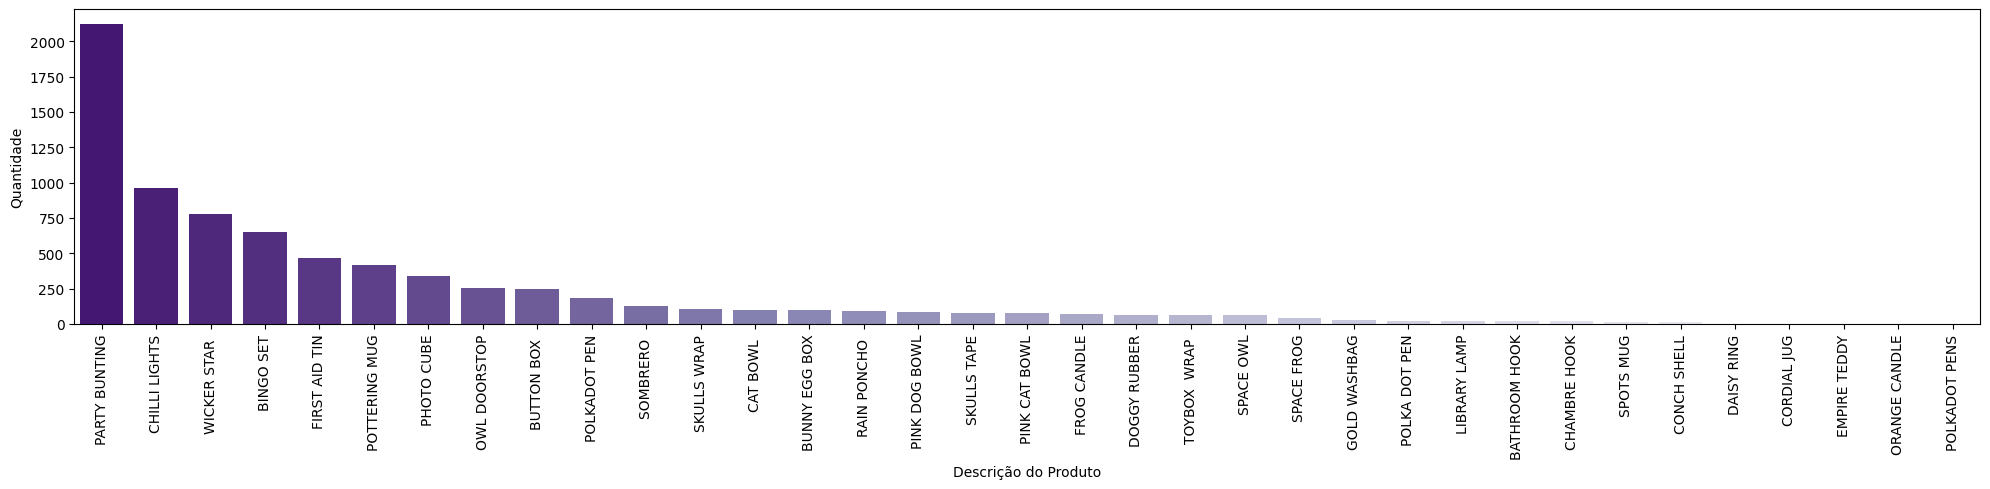

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem das descrições com comprimento menor que 14 caracteres
contagem_descricoes_curtas = (
    data.loc[data.DescriptionLength < 14, "Description"]
    .value_counts()
)

# Criação da figura
plt.figure(figsize=(20, 5))

# Gráfico de barras das descrições curtas
sns.barplot(
    x=contagem_descricoes_curtas.index,
    y=contagem_descricoes_curtas.values,
    palette="Purples_r"
)

plt.xlabel("Descrição do Produto")
plt.ylabel("Quantidade")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [180]:
data.StockCode.nunique()

3317

In [181]:
data.Description.nunique()

3889

In [182]:
data.groupby("StockCode").Description.nunique().sort_values(ascending=False).iloc[0:10]

StockCode
22384    4
23236    4
23196    4
22345    4
22346    4
21955    4
20685    4
22344    4
23535    3
22852    3
Name: Description, dtype: int64

In [183]:
data.loc[data.StockCode == "21955"].Description.value_counts()

Description
DOORMAT UNION JACK GUNS AND ROSES      292
DOOR MAT UNION JACK GUNS AND ROSES     168
UNION JACK GUNS & ROSES  DOORMAT        88
  DOORMAT UNION JACK GUNS AND ROSES     53
Name: count, dtype: int64

# Clientes

In [184]:
data.CustomerID.nunique()

5818

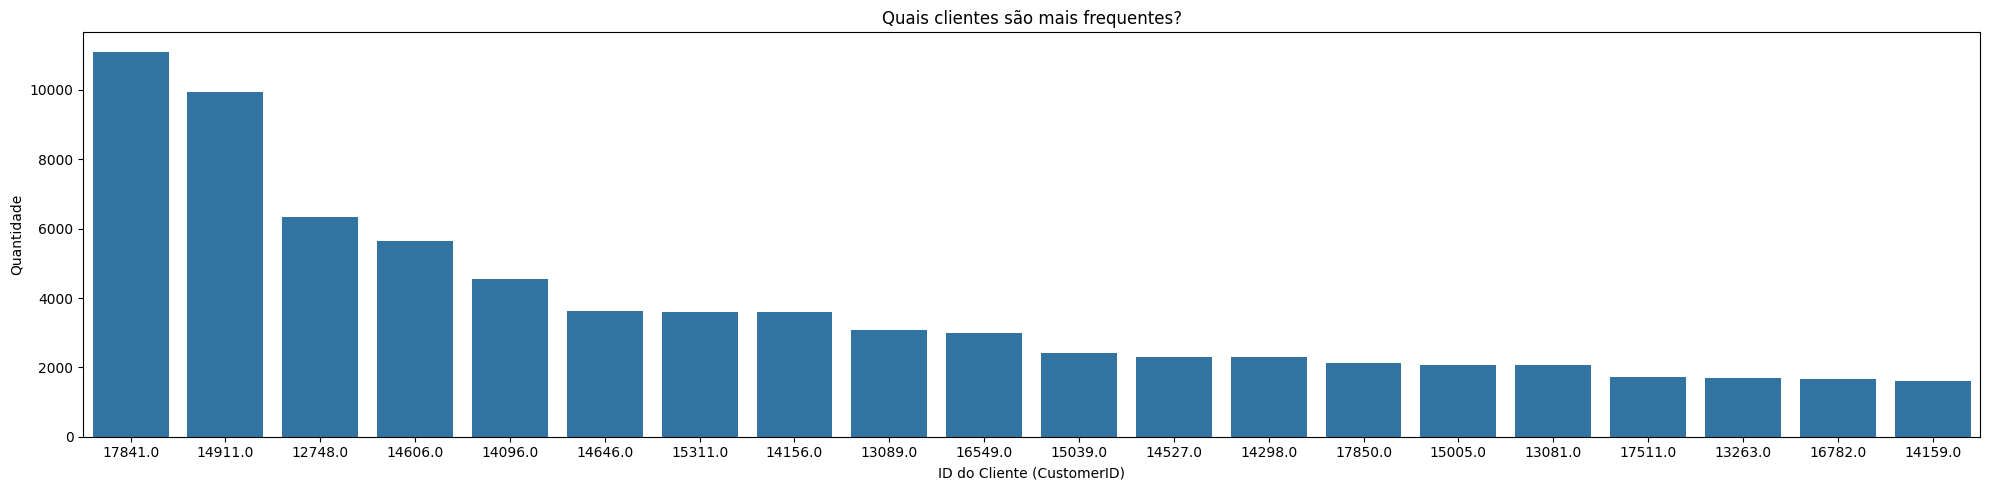

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem dos clientes mais frequentes (top 20)
contagem_clientes = (
    data.CustomerID.value_counts()
    .sort_values(ascending=False)
    .iloc[:20]
)

# Criação da figura
plt.figure(figsize=(20, 5))

# Gráfico de barras dos clientes mais comuns
sns.barplot(
    x=contagem_clientes.index,
    y=contagem_clientes.values,
    order=contagem_clientes.index
)

plt.ylabel("Quantidade")
plt.xlabel("ID do Cliente (CustomerID)")
plt.title("Quais clientes são mais frequentes?")

plt.tight_layout()
plt.show()

# Países

Para quantos países diferentes o varejista realiza entregas?

In [186]:
data.Country.nunique()

41

E quais são os mais comuns?

/tmp/ipykernel_118024/2923392982.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


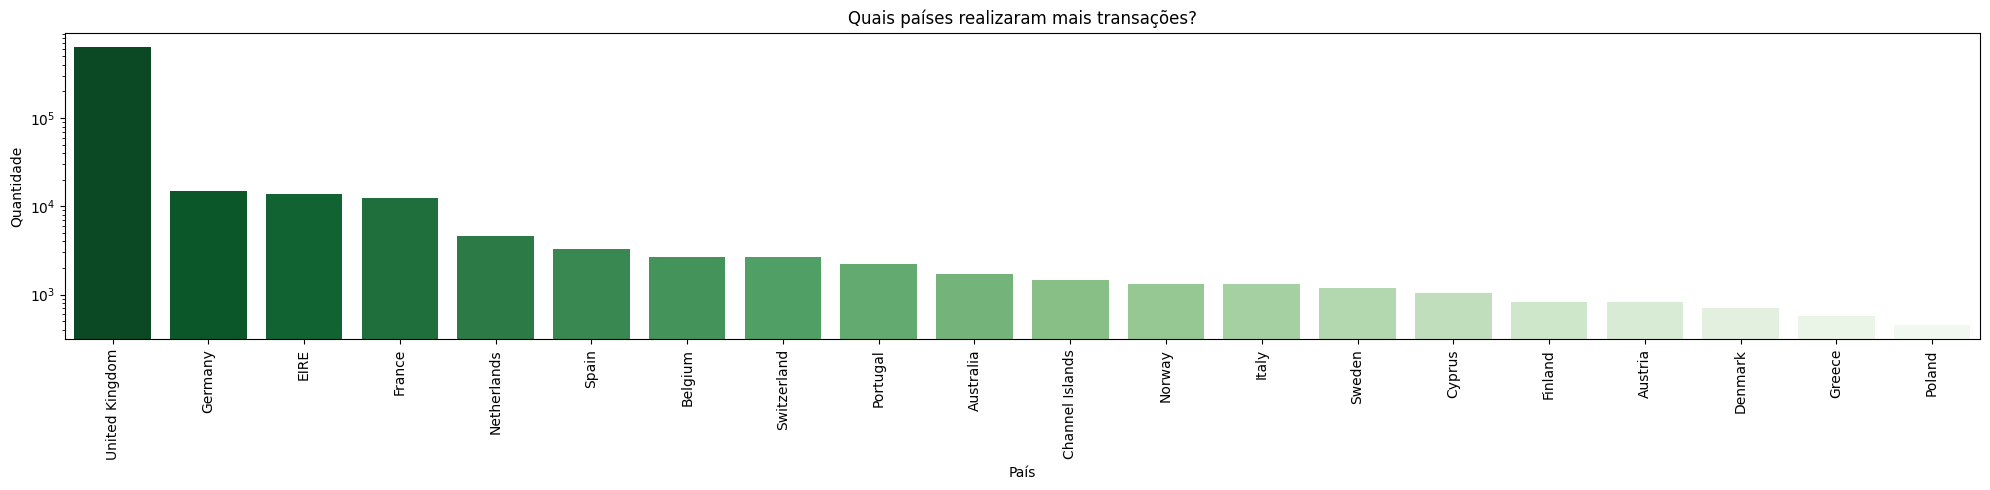

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem dos países com mais transações (top 20)
contagem_paises = (
    data.Country.value_counts()
    .sort_values(ascending=False)
    .iloc[:20]
)

# Criação da figura
plt.figure(figsize=(20, 5))

# Gráfico de barras dos países com mais transações
sns.barplot(
    x=contagem_paises.index,
    y=contagem_paises.values,
    palette="Greens_r"
)

plt.ylabel("Quantidade")
plt.xlabel("País")
plt.title("Quais países realizaram mais transações?")
plt.xticks(rotation=90)

# Escala logarítmica no eixo Y
plt.yscale("log")

plt.tight_layout()
plt.show()

In [188]:
data.loc[data.Country=="United Kingdom"].shape[0] / data.shape[0] * 100

89.97223196129303

Vamos criar uma funcionalidade para indicar se está dentro ou fora do Reino Unido:

In [189]:
data["UK"] = np.where(data.Country == "United Kingdom", 1, 0)

# Preço unitário

In [190]:
data.UnitPrice.describe()

count    713050.000000
mean          2.932361
std           4.394009
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max         649.500000
Name: UnitPrice, dtype: float64

Mais uma vez, temos ocorrências estranhas: preços unitários zerados!

In [191]:
data.loc[data.UnitPrice == 0].sort_values(by="Quantity", ascending=False).head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,lowercase_descriptions,DescriptionLength,LowCharsInDescription,UpCharsInDescription,UK
1027583,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.0,13256.0,United Kingdom,asstd design 3d paper stickers,30,0,25,1
823515,562973,23157,SET OF 6 NATIVITY MAGNETS,240,2011-08-11 11:42:00,0.0,14911.0,EIRE,set of 6 nativity magnets,26,0,20,0
961889,574138,23234,BISCUIT TIN VINTAGE CHRISTMAS,216,2011-11-03 11:26:00,0.0,12415.0,Australia,biscuit tin vintage christmas,29,0,26,0
840207,564651,23268,SET OF 2 CERAMIC CHRISTMAS REINDEER,192,2011-08-26 14:19:00,0.0,14646.0,Netherlands,set of 2 ceramic christmas reindeer,35,0,29,0
840209,564651,21786,POLKADOT RAIN HAT,144,2011-08-26 14:19:00,0.0,14646.0,Netherlands,polkadot rain hat,18,0,15,0


In [192]:
print("Antes:", len(data))

Antes: 713050


In [193]:
data = data.loc[data.UnitPrice > 0].copy()

In [194]:
print("Depois:", len(data))

Depois: 712991


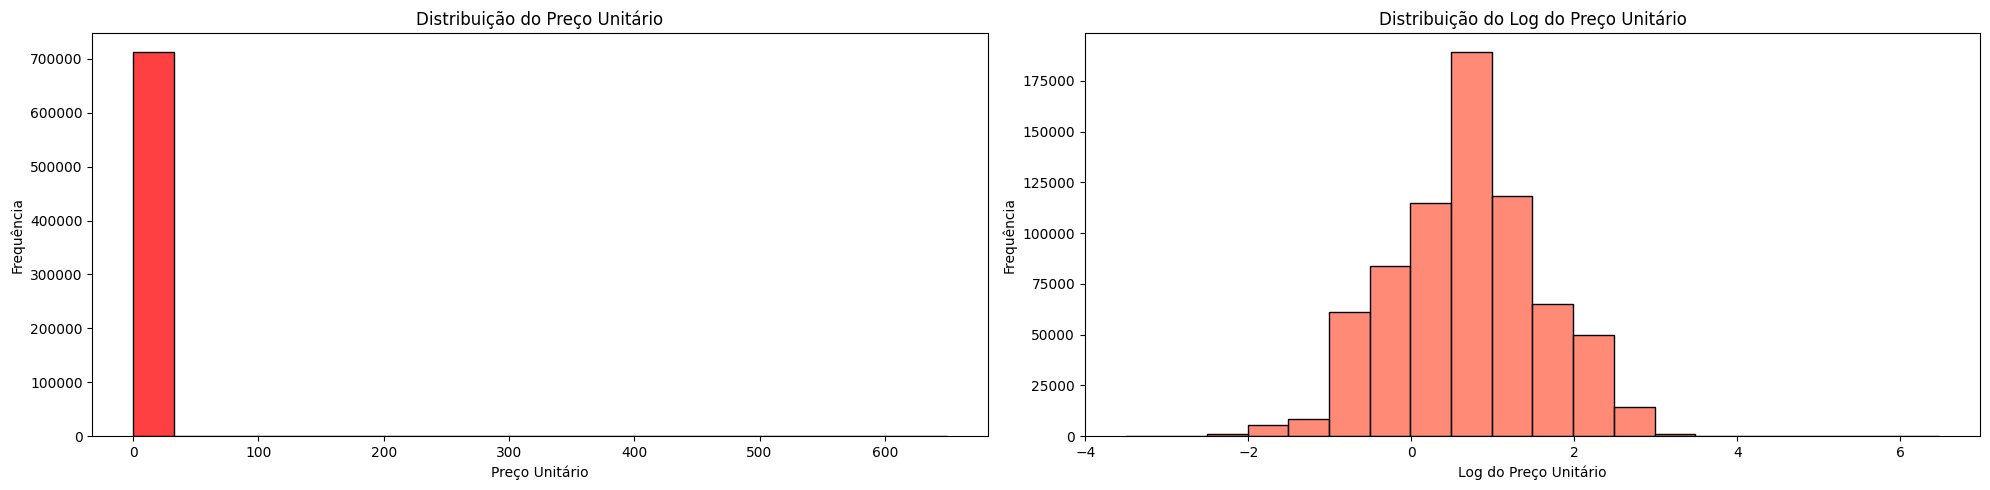

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Criação da figura com dois subgráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

# Histograma do preço unitário
sns.histplot(
    data.UnitPrice,
    ax=ax[0],
    bins=20,
    color="red"
)

ax[0].set_xlabel("Preço Unitário")
ax[0].set_ylabel("Frequência")
ax[0].set_title("Distribuição do Preço Unitário")

# Histograma do logaritmo do preço unitário
sns.histplot(
    np.log(data.UnitPrice),
    ax=ax[1],
    bins=20,
    color="tomato"
)

ax[1].set_xlabel("Log do Preço Unitário")
ax[1].set_ylabel("Frequência")
ax[1].set_title("Distribuição do Log do Preço Unitário")

plt.tight_layout()
plt.show()

In [196]:
np.exp(-2)

np.float64(0.1353352832366127)

In [197]:
np.exp(3)

np.float64(20.085536923187668)

In [198]:
np.quantile(data.UnitPrice, 0.95)

np.float64(8.5)

Vamos nos concentrar em transações com preços que se enquadrem nessa faixa, pois não queremos fazer previsões para produtos raros com preços elevados. Começar devagar é sempre uma boa ideia!

In [199]:
print("Antes:", len(data))

Antes: 712991


In [200]:
data = data.loc[(data.UnitPrice > 0.1) & (data.UnitPrice < 20)].copy()

In [201]:
print("Depois:", len(data))

Depois: 711545


# Quantidades

In [202]:
data.Quantity.describe()

count    711545.000000
mean         13.052836
std         142.657653
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

Ok, a maioria dos produtos é vendida em quantidades de 1 a 12. Mas, novamente, temos casos extremos e irreais:

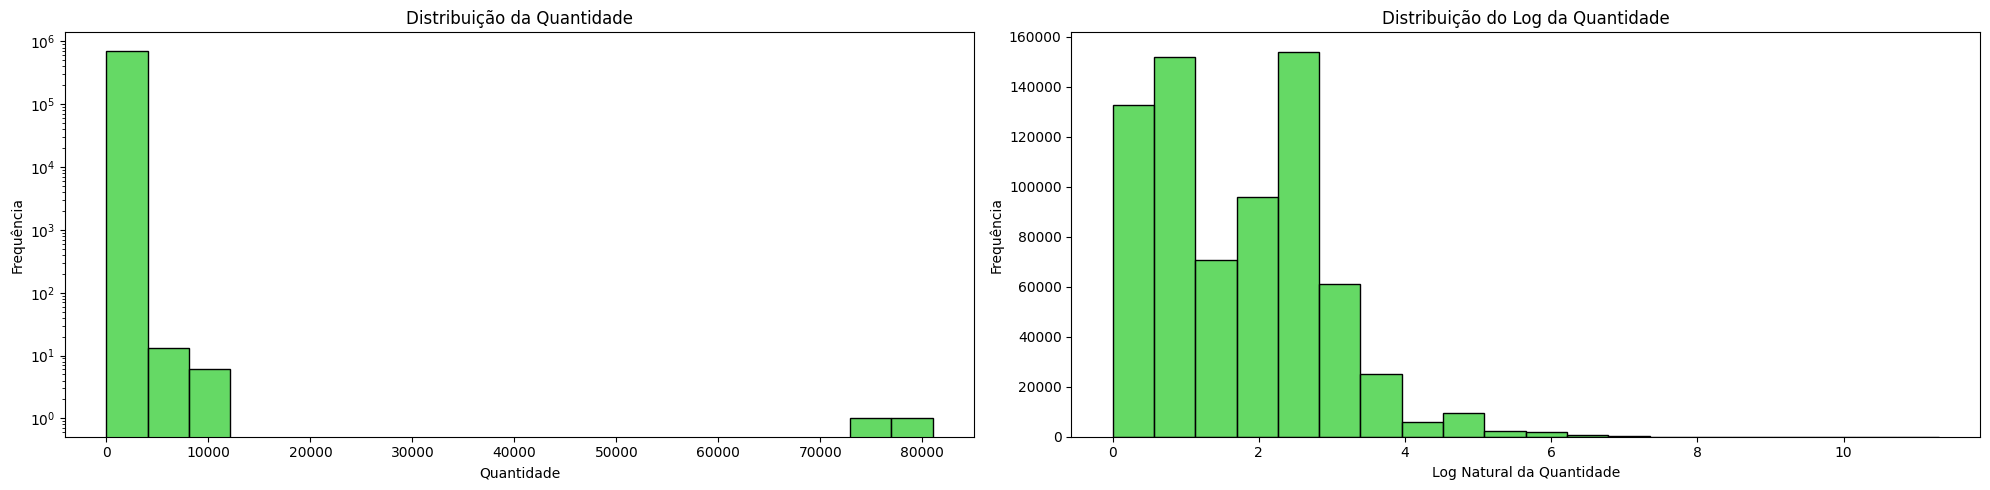

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Criação da figura com dois subgráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

# Histograma da quantidade
sns.histplot(
    data.Quantity,
    ax=ax[0],
    bins=20,
    color="limegreen"
)

ax[0].set_title("Distribuição da Quantidade")
ax[0].set_xlabel("Quantidade")
ax[0].set_ylabel("Frequência")
ax[0].set_yscale("log")

# Histograma do logaritmo natural da quantidade
sns.histplot(
    np.log(data.Quantity),
    ax=ax[1],
    bins=20,
    color="limegreen"
)

ax[1].set_title("Distribuição do Log da Quantidade")
ax[1].set_xlabel("Log Natural da Quantidade")
ax[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

Como você pode ver pela distribuição transformada por logaritmo, faria sentido fazer um corte em:

In [204]:
np.exp(4)

np.float64(54.598150033144236)

In [205]:
np.quantile(data.Quantity, 0.95)

np.float64(36.0)

Nesse caso, ainda assim cobriríamos mais de 95% dos dados!

In [206]:
print("Antes:", len(data))

Antes: 711545


In [207]:
data = data.loc[data.Quantity < 55].copy()

In [208]:
print("Depois:", len(data))

Depois: 691471


# Receitas

### Foque nas vendas diárias de produtos.
Precisamos calcular uma agregação diária desses dados. Para isso, precisamos extrair características temporais da data da fatura (InvoiceDate). Além disso, podemos calcular a receita obtida por transação usando o preço unitário e a quantidade:

In [209]:
# Criação da coluna de faturamento
data["Revenue"] = data.Quantity * data.UnitPrice

# Extração de componentes temporais da data da fatura
data["Year"] = data.InvoiceDate.dt.year
data["Quarter"] = data.InvoiceDate.dt.quarter
data["Month"] = data.InvoiceDate.dt.month

# Semana do ano (padrão ISO)
data["Week"] = data.InvoiceDate.dt.isocalendar().week.astype(int)

# Dia da semana (0 = segunda, 6 = domingo)
data["Weekday"] = data.InvoiceDate.dt.weekday

# Dia do mês
data["Day"] = data.InvoiceDate.dt.day

# Dia do ano
data["DayOfYear"] = data.InvoiceDate.dt.dayofyear

# Data normalizada (YYYY-MM-DD)
data["Date"] = pd.to_datetime({
    "year": data["Year"],
    "month": data["Month"],
    "day": data["Day"]
})

In [210]:
grouped_features = ["InvoiceNo", "InvoiceDate", "Date", "Year", "Month", "Day", "Quarter",
       "Week", "Weekday", "DayOfYear", "StockCode", "CustomerID", "Country",
       "Description", "UnitPrice"]

In [211]:
daily_data = pd.DataFrame(data.groupby(grouped_features).Quantity.sum(),
                          columns=["Quantity"])
daily_data["Revenue"] = data.groupby(grouped_features).Revenue.sum()
daily_data = daily_data.reset_index()
daily_data.head(5)

,InvoiceNo,InvoiceDate,Date,Year,Month,Day,Quarter,Week,Weekday,DayOfYear,StockCode,CustomerID,Country,Description,UnitPrice,Quantity,Revenue
0,489434,2009-12-01 07:45:00,2009-12-01,2009,12,1,4,49,1,335,21232,13085.0,United Kingdom,STRAWBERRY CERAMIC TRINKET BOX,1.25,24,30.0
1,489434,2009-12-01 07:45:00,2009-12-01,2009,12,1,4,49,1,335,21523,13085.0,United Kingdom,FANCY FONT HOME SWEET HOME DOORMAT,5.95,10,59.5
2,489434,2009-12-01 07:45:00,2009-12-01,2009,12,1,4,49,1,335,21871,13085.0,United Kingdom,SAVE THE PLANET MUG,1.25,24,30.0
3,489434,2009-12-01 07:45:00,2009-12-01,2009,12,1,4,49,1,335,22041,13085.0,United Kingdom,"RECORD FRAME 7"" SINGLE SIZE",2.10,48,100.8
4,489434,2009-12-01 07:45:00,2009-12-01,2009,12,1,4,49,1,335,22064,13085.0,United Kingdom,PINK DOUGHNUT TRINKET POT,1.65,24,39.6


In [212]:
daily_data.loc[:, ["Quantity", "Revenue"]].describe()

,Quantity,Revenue
count,659157.000000,659157.000000
mean,8.647691,16.440712
std,9.690022,22.012170
min,1.000000,0.120000
25%,2.000000,5.040000
50%,6.000000,12.500000
75%,12.000000,18.750000
max,144.000000,1190.400000


Como podemos ver pelos valores mínimo e máximo, a variável alvo apresenta outliers extremos. Se quisermos usá-la como alvo, devemos excluí-los, pois eles podem distorcer nossa validação. Como gosto de usar o método de parada antecipada, isso também influenciará diretamente o treinamento dos modelos preditivos.

In [213]:
low_quantity = daily_data.Quantity.quantile(0.01)
high_quantity = daily_data.Quantity.quantile(0.99)
print((low_quantity, high_quantity))

(np.float64(1.0), np.float64(48.0))


In [214]:
low_revenue = daily_data.Revenue.quantile(0.01)
high_revenue = daily_data.Revenue.quantile(0.99)
print((low_revenue, high_revenue))

(np.float64(0.65), np.float64(102.0))


Vamos usar apenas os intervalos de dados que representam 90% das entradas. Essa é uma estratégia inicial e simples para excluir valores discrepantes significativos, mas devemos sempre ter em mente que perdemos informações importantes devido à porcentagem restante que excluímos. Seria interessante e útil, de modo geral, entender e analisar as causas desses valores discrepantes.

In [215]:
samples = daily_data.shape[0]

In [216]:
print("Antes:", len(daily_data))

Antes: 659157


In [217]:
daily_data = daily_data.loc[
    (daily_data.Quantity >= low_quantity) & (daily_data.Quantity <= high_quantity)]
daily_data = daily_data.loc[
    (daily_data.Revenue >= low_revenue) & (daily_data.Revenue <= high_revenue)]

In [218]:
print("Depois:", len(daily_data))

Depois: 646325


Quantas transações perdemos?

In [219]:
samples - daily_data.shape[0]

12832

Vejamos as distribuições restantes das quantidades diárias:

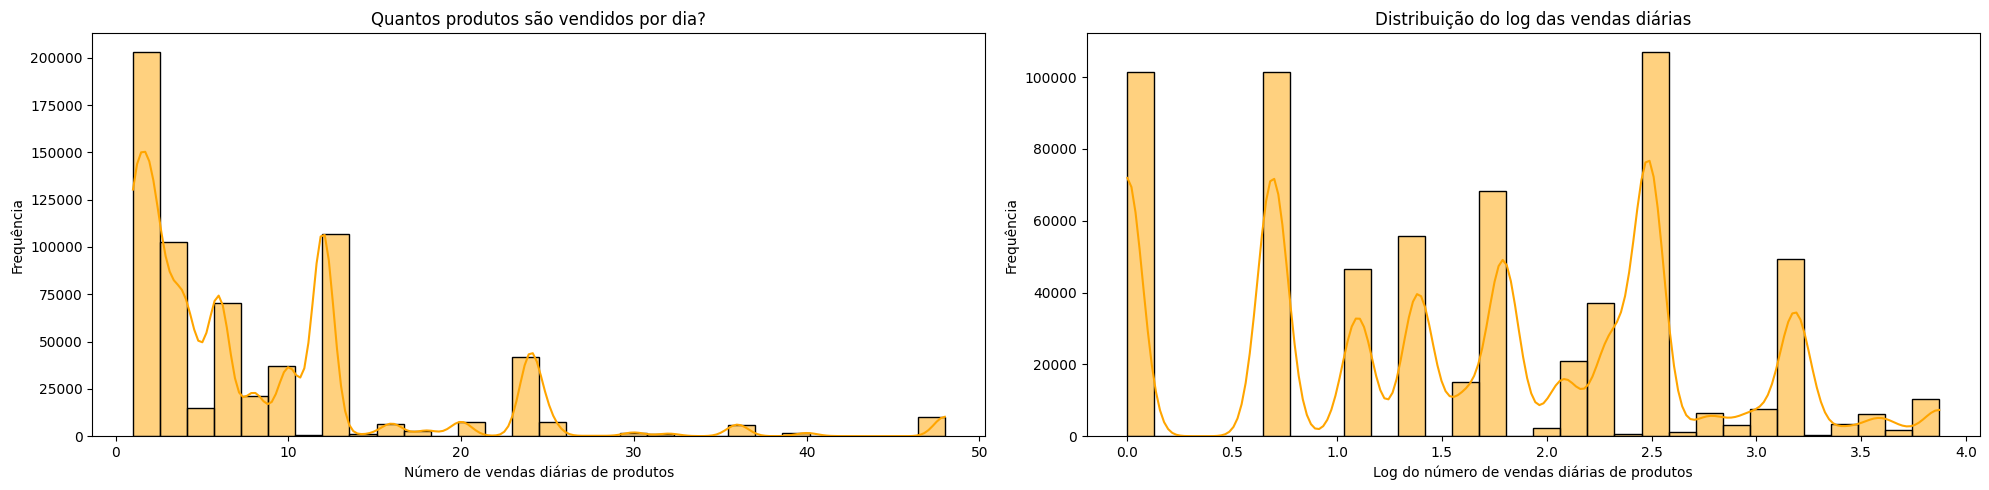

In [220]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Criação da figura com dois subgráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

# Distribuição da quantidade diária vendida
sns.histplot(
    daily_data["Quantity"].values,
    bins=30,
    kde=True,
    ax=ax[0],
    color="Orange"
)

ax[0].set_xlabel("Número de vendas diárias de produtos")
ax[0].set_ylabel("Frequência")
ax[0].set_title("Quantos produtos são vendidos por dia?")

# Distribuição do logaritmo da quantidade diária vendida
sns.histplot(
    np.log(daily_data["Quantity"].values),
    bins=30,
    kde=True,
    ax=ax[1],
    color="Orange"
)

ax[1].set_xlabel("Log do número de vendas diárias de produtos")
ax[1].set_ylabel("Frequência")
ax[1].set_title("Distribuição do log das vendas diárias")

plt.tight_layout()
plt.show()

# Salvar os dados limpos

In [ ]:
daily_data.to_csv("data/cleaned_online_retail_II.csv", index=False)